# ICESat-2 ATL21 Matchups

ATL21 is the gridded sea surface height anomaly (SSHA) product derived from ICESat-2 sea-ice measurements. Because it is a gridded product, we can use `point-collocation` to do matchups. Other ICESat-2 products like ATL07 are along track (lines) and `point-collocation` will not work for those data.

ATL21 has
* Daily Arctic/Antarctic SSHA fields
* Monthly averaged SSHA fields

The granules are h5 grouped netcdf files. It has monthly, daily, and metadata all in one netcdf.

## First generate some points over the arctic

In [2]:
import numpy as np
import pandas as pd

n_points = 50

# generate Arctic points (lat > 60)
points = []
while len(points) < n_points:
    batch = 500
    lat = np.degrees(np.arcsin(np.random.uniform(-1, 1, batch)))
    lon = np.random.uniform(-180, 180, batch)

    mask = lat > 75
    for la, lo in zip(lat[mask], lon[mask]):
        points.append((la, lo))
        if len(points) >= n_points:
            break

lat, lon = np.array(points).T

# random dates after Oct 2018
start = pd.Timestamp("2018-10-01")
end = pd.Timestamp.now()

days = pd.date_range(start, end, freq="D")
date = np.random.choice(days, n_points)

# dataframe
df = pd.DataFrame({
    "lat": lat,
    "lon": lon,
    "date": date
})

print(df.head())

         lat         lon       date
0  75.335363   61.929180 2022-03-07
1  88.342307 -150.168110 2024-12-28
2  75.697007  127.289327 2024-03-24
3  82.851837 -101.584590 2021-05-26
4  83.636097 -102.690326 2019-11-03


### Next get the granule plan

In [16]:
import point_collocation as pc
import pandas as pd
short_name="ATL21"
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
        "version": "004"
    }
)

In [17]:
# Some points are probably over land
plan.summary(n=0)

Plan: 50 points → 32 unique granule(s)
  Points with 0 matches : 2
  Points with >1 matches: 0
  Time buffer: 0 days 00:00:00


### Show the groups in the files

`plan.show_variables()` will open a granules and show us the groups. This will be verbose but will help us see what groups we want. This uses `open_method="auto"` which is not what we want but is enough to see what the groups are. If you scroll to the bottom, you will see that it could not find the lat/lon variables.

Looking at this, we see we want groups `"/"` and `"/monthly"`. Unfortunately, getting the daily values from these files would require setting a time variable somehow. The coords are `grid_lat` and `grid_lon`.

In [12]:
%%time
plan.show_variables()

open_method: {'xarray_open': 'auto', 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'coords': 'auto', 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None}

Group /
  Dimensions: {'grid_y': 448, 'grid_x': 304, 'dim_0': 304}
  Variables:  crs(), grid_lat('grid_y', 'grid_x'), grid_lon('grid_y', 'grid_x'), grid_x('dim_0',), grid_y('dim_0',), land_mask_map('grid_y', 'grid_x')

Group /METADATA
  Dimensions: {'dim_0': 1}
  Variables:  iso_19139_dataset_xml('dim_0',), iso_19139_series_xml('dim_0',)

Group /METADATA/AcquisitionInformation

Group /METADATA/AcquisitionInformation/lidar

Group /METADATA/AcquisitionInformation/lidarDocument

Group /METADATA/AcquisitionInformation/platform

Group /METADATA/AcquisitionInformation/platformDocument

Group /METADATA/DataQuality

Group /METADATA/DataQuality/CompletenessOmission

Group /METADATA/DataQuality/DomainConsistency

Group /METADATA/DatasetIdentification

Group /METADATA/Extent

Group /METADATA/

### Specify a `open_method` profile

Now that we know what the groups are and what the latitude and longitude are called, we can set up a `open_method` profile. This is used to tell `point-collocation` how to open the file (`open_dataset` or `open_datatree` and what groups (if any) to merge. Note, `open_dataset` and merge is faster than `open_datatree` and merge.

Let's open one file and plot our points on that data. A bunch of points are on land and those will be NaN. A few points are on white (NaN) and those will be NaN also.

In [18]:
%%time
icesat2_atl21 = {
    'xarray_open': 'dataset',
    'merge': ['/', '/monthly'],
    'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False, 'phony_dims': 'sort'},
    'coords': {'lat': 'grid_lat', 'lon': 'grid_lon'},
    'set_coords': True,
}
dt2 = plan.open_dataset(plan[0], open_method=icesat2_atl21)

CPU times: user 1.57 s, sys: 10.5 ms, total: 1.58 s
Wall time: 1.69 s


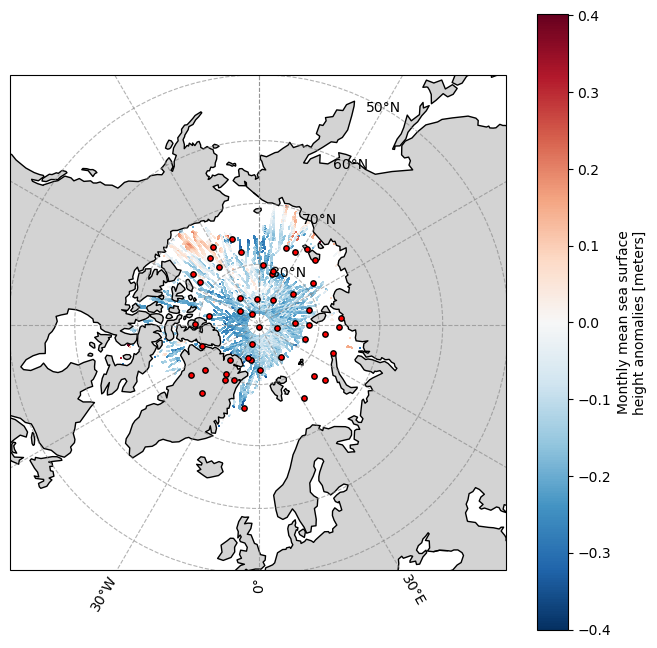

In [19]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

# plot the field
dt2.mean_ssha.plot.pcolormesh(
    x="grid_lon",
    y="grid_lat",
    transform=ccrs.PlateCarree(),
    ax=ax,
    shading="auto",
    add_colorbar=True,
)

ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor="lightgray")

# Arctic extent
ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())

# gridlines
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.8,
    color="gray",
    alpha=0.6,
    linestyle="--",
)

gl.top_labels = False
gl.right_labels = False
gl.xlocator = plt.FixedLocator(np.arange(-180, 181, 30))
gl.ylocator = plt.FixedLocator(np.arange(50, 91, 10))

# ---- add points from dataframe ----
ax.scatter(
    df.lon,
    df.lat,
    transform=ccrs.PlateCarree(),
    s=15,
    color="red",
    edgecolor="black",
    zorder=10,
)

plt.show()

In [ ]:
%%time
# this takes about 2 minutes
res = pc.matchup(plan, 
                 variables = ["mean_ssha"], 
                 open_method=icesat2_atl21,
                 spatial_method="xoak")

The full `res` output shows the granules and granules closest lat/lon. Here is just the matchups.

In [23]:
res[['lat', 'lon', 'time', 'mean_ssha']].dropna(subset=['mean_ssha'])

,lat,lon,time,mean_ssha
2,85.220474,149.930499,2019-01-18 12:00:00,-0.192034
3,78.376089,-145.026835,2019-01-18 12:00:00,-0.117620
11,86.520073,-18.274879,2019-10-13 12:00:00,-0.102046
13,84.046653,-18.159051,2020-03-16 12:00:00,-0.149427
14,81.545401,-99.980171,2020-05-05 12:00:00,-0.264338
15,80.720945,165.106976,2020-05-22 12:00:00,-0.221109
16,83.455607,34.289036,2020-07-04 12:00:00,-0.095293
17,80.049427,176.091898,2020-08-06 12:00:00,-0.234110
19,76.264785,-143.783821,2020-09-22 12:00:00,-0.145541
22,81.259284,165.112196,2020-10-05 12:00:00,-0.164445
